In [62]:
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from matplotlib.ticker import FuncFormatter
from matplotlib.dates import *

In [63]:
from config import DRIVER as driver

In [64]:
def to_list(cursor):
    return list(map(dict, cursor))

def to_data_frame(cursor):
    return pd.DataFrame(to_list(cursor))

def get_transactions(ind, am):
    url = "http://127.0.0.1:28081/get_outs"
    # Define the JSON payload
    payload = {"outputs":[{"amount": am, "index":ind}], "get_txid": True}
    # Define the headers
    headers = {
        "Content-Type": "application/json"
    }

    # Make the POST request
    response = requests.post(url, json=payload, headers=headers)
    return response.json()

First we will get the number of inputs with a mix in equal to 0. Remember this data has been creaed in a local tesnet, so the number with mixin equal to 0 may be elevated to show the privicy risk of using mixin 0. Rememebre that mixin 0 is not recommended for privacy reasons and you can no longer use it in the Monero main network.

In [65]:
with driver.session() as session:
    num_inputs = to_list(session.run(query=  """MATCH (i:Input) RETURN count(i)"""))[0]['count(i)']
    num_inputs_mix_0 = to_list(session.run(query=  """MATCH (i:Input) WHERE i.mixin = '0' RETURN count(i)"""))[0]['count(i)']

print(f"Number of inputs: {num_inputs}")
print(f"\nNumber of inputs with mixin equal to 0: {num_inputs_mix_0}. This inputs do not have the benefits of ring signatures")

Number of inputs: 4641

Number of inputs with mixin equal to 0: 766. This inputs do not have the benefits of ring signatures


Our next step is to get all the information of those inputs with mixins equal to 0 to see what information we can get from them.

In [66]:
query = """MATCH (i:Input)-[:TX_INPUT]->(t:Transactions)
            WHERE i.mixin = '0'
            RETURN i, t"""

with driver.session() as session:
    data = to_list(session.run(query=query))
    
    rows = []
    for record in data:
        input_node = record['i']
        transaction_node = record['t']
        row = {
                    'input_mixin': input_node.get('mixin'),
                    'input_anonset': input_node.get('anonset'),
                    'input_id': input_node.get('id'),
                    'input_value': input_node.get('value'),
                    'key_offset': input_node.get('key_offset'),
                    'transaction_fee': transaction_node.get('fee'),
                    'transaction_id': transaction_node.get('id'),
                    'transaction_hash': transaction_node.get('hash')
                }
        rows.append(row)
inputs = pd.DataFrame(rows)
inputs

,input_mixin,input_anonset,input_id,input_value,key_offset,transaction_fee,transaction_id,transaction_hash
0,0,63,i0,90000000000,[3],4268127321,t65,fbc9c915ebe08091e4bd58d039289c169dd1852a481715...
1,0,64,i1,10000000000000,[2],4268127321,t65,fbc9c915ebe08091e4bd58d039289c169dd1852a481715...
2,0,64,i2,10000000000000,[1],4268127321,t65,fbc9c915ebe08091e4bd58d039289c169dd1852a481715...
3,0,65,i3,7000000000000,[0],2458473645,t66,059b07e3ab70b55b93339026dd021e3bc5f1c65d70b11b...
4,0,65,i4,10000000000000,[3],3212403907,t67,6d6377e0fa4143181e7ac1b36216ad7e3d50a4309a7c43...
...,...,...,...,...,...,...,...,...
761,0,26,i761,9000000000000,[19],4946746849,t390,3115a8abbc0fe5b14b7ba1c996957df72c8703809337ef...
762,0,334,i762,10000000000000,[63],4946746849,t390,3115a8abbc0fe5b14b7ba1c996957df72c8703809337ef...
763,0,216,i763,90000000000,[144],4946746849,t390,3115a8abbc0fe5b14b7ba1c996957df72c8703809337ef...
764,0,59,i764,600000000000,[36],4946746849,t390,3115a8abbc0fe5b14b7ba1c996957df72c8703809337ef...


Notice that there are key_offset that repeat. This is because the key_offset it point us at the output of some previous block, and that block can have multiple output. Is the key (which is an information will get on the next steps) along with the key_offset that will help us to identify the output that is being spent.

In [67]:
k_offsets_mix_0 = {}
tx_used = []
for _, row in inputs[['input_value', 'key_offset', 'transaction_hash']].iterrows():
    key_offset = row.key_offset.split('[')[1].split(']')[0]
    value = row.input_value
    outs = get_transactions(int(key_offset), int(value))
    if key_offset not in k_offsets_mix_0.keys():
        k_offsets_mix_0[key_offset] = [{'block': outs['outs'][0]['height'], 'key': outs['outs'][0]['key'], 'amount': value }]
    else:
        k_offsets_mix_0[key_offset].append({'block': outs['outs'][0]['height'], 'key': outs['outs'][0]['key'], 'amount': value })
    tx_used.append(outs['outs'][0]['key'])

With this last dictionary, we have the information of each key_offset used in the transactions with mixin equal to 0. As the mixins is 0, the transactions that appears is 100% the one being spend. If this key it is used in another transaction, we will know that it is not the real one as it has been previosuly spent.

In [68]:
query = """MATCH (i:Input)-[:TX_INPUT]->(t:Transactions)
            WHERE i.mixin <> '0'
            RETURN i, t"""

with driver.session() as session:
    data = to_list(session.run(query=query))
    
    rows = []
    for record in data:
        input_node = record['i']
        transaction_node = record['t']
        row = {
                    'input_mixin': input_node.get('mixin'),
                    'input_anonset': input_node.get('anonset'),
                    'input_id': input_node.get('id'),
                    'input_value': input_node.get('value'),
                    'key_offset': input_node.get('key_offset'),
                    'transaction_fee': transaction_node.get('fee'),
                    'transaction_id': transaction_node.get('id'),
                    'transaction_hash': transaction_node.get('hash')
                }
        rows.append(row)
inputs_mul_mix = pd.DataFrame(rows)
inputs_mul_mix

,input_mixin,input_anonset,input_id,input_value,key_offset,transaction_fee,transaction_id,transaction_hash
0,1,351,i767,10000000000000,"[182, 126]",2812564057,t407,53d0a3e54acaab8d3083e72d81b9afdeded7081894b1ca...
1,1,28,i766,4000000000000,"[21, 3]",2812564057,t407,53d0a3e54acaab8d3083e72d81b9afdeded7081894b1ca...
2,1,353,i769,10000000000000,"[232, 47]",4995647194,t410,3120ca4227a2845f24882dd55410354b9b01f626f4f0f5...
3,1,38,i770,700000000000,"[20, 5]",4995647194,t410,3120ca4227a2845f24882dd55410354b9b01f626f4f0f5...
4,1,47,i768,7000000000,"[15, 19]",4995647194,t410,3120ca4227a2845f24882dd55410354b9b01f626f4f0f5...
...,...,...,...,...,...,...,...,...
3870,9,1600,i4640,10000000000000,"[321, 109, 91, 230, 243, 69, 82, 49, 61, 145]",14954818413,t1891,118057d4d2998cefaebd659e83444d6d60114146b6a798...
3871,9,144,i4637,900000000000,"[44, 15, 24, 17, 3, 4, 1, 4, 2, 9]",14954818413,t1891,118057d4d2998cefaebd659e83444d6d60114146b6a798...
3872,9,1095,i4633,500000000000,"[120, 242, 194, 42, 313, 37, 6, 5, 2, 30]",14954818413,t1891,118057d4d2998cefaebd659e83444d6d60114146b6a798...
3873,9,293,i4639,600000000000,"[118, 25, 10, 19, 11, 13, 25, 15, 12, 21]",14954818413,t1891,118057d4d2998cefaebd659e83444d6d60114146b6a798...


In [69]:
for x,row in inputs.iterrows():
    if row.key_offset.split('[')[0] == '103' or row.key_offset.split('[')[0] == '46':
        print(x)

In [70]:
get_transactions(103, 90000000000)

{'credits': 0,
 'outs': [{'height': 99,
   'key': '82917ac11dabaccb4c503d051700a9724d1096ed01d4aad8aac1944d07b653c8',
   'mask': 'b747fc01c6f0c749673a2910250c2e23cb38274d63b42f521b846356e413618f',
   'txid': '666dcd0da94c6ff94c47d0f306057bdc566ab2b03c197c075e4c9fc11c90ea1f',
   'unlocked': True}],
 'status': 'OK',
 'top_hash': '',
 'untrusted': False}

In [71]:
get_transactions(46, 90000000000)

{'credits': 0,
 'outs': [{'height': 47,
   'key': '07e4d1629d1b6ec2b0fe288cad9919391387df0145cf7c8c3f09c86739ef2a9d',
   'mask': 'b747fc01c6f0c749673a2910250c2e23cb38274d63b42f521b846356e413618f',
   'txid': '2a20abd368156d6f397b25716a0499f2ae6901ea2d073e8eb28901f24e1a339b',
   'unlocked': True}],
 'status': 'OK',
 'top_hash': '',
 'untrusted': False}

In [72]:
total_mixins = {'1': 0, '3': 0, '9': 0} 
vul_mixins = {'1': 0, '3': 0, '9': 0}
for x, row in inputs_mul_mix[['input_value', 'key_offset', 'transaction_hash', 'input_mixin']][:980].iterrows():
    key_offset = row.key_offset.split('[')[1].split(']')[0].split(',')
    value = row.input_value
    num_mixin = row.input_mixin
    count = 0
    for i, key in enumerate(key_offset):
        total_mixins[str(num_mixin)] += 1
        key_i = int(key)
        out = get_transactions(key_i, int(value))
        if out['outs'][0]['key'] in tx_used:
            if num_mixin == 1:
                # If a transaction with 2 inputs uses one of the used inputs of our list,
                # we can also addthe other input in the list since it will be another used output
                tx_used.append(get_transactions(int(key_offset[1-i]), int(value))['outs'][0]['key'])
            vul_mixins[str(num_mixin)] += 1

In [73]:
print('Percentage of deducable mixins when ring size is 2: ',vul_mixins['1']/total_mixins['1'])
print('Percentage of deducable mixins when ring size is 4: ',vul_mixins['3']/total_mixins['3'])
print('Percentage of deducable mixins when ring size is 10: ',vul_mixins['9']/total_mixins['9'])

Percentage of deducable mixins when ring size is 2:  0.3106060606060606
Percentage of deducable mixins when ring size is 4:  0.4846698113207547
Percentage of deducable mixins when ring size is 10:  0.6079166666666667


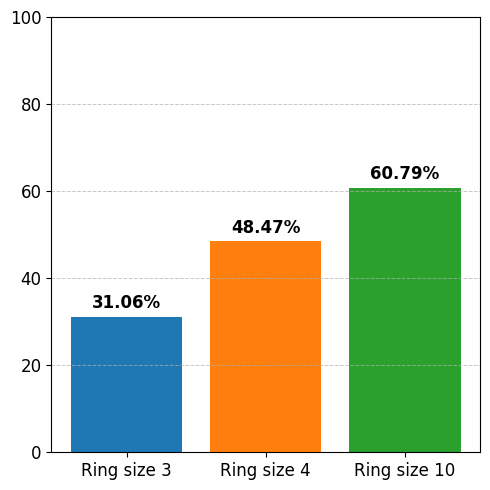

In [74]:
import matplotlib.pyplot as plt

# Labels for the percentages
labels = ['Ring size 3', 'Ring size 4', 'Ring size 10']
percentages = [round(vul_mixins['1']/total_mixins['1']*100, 2), round(vul_mixins['3']/total_mixins['3']*100, 2), round(vul_mixins['9']/total_mixins['9']*100, 2)]

# Create the bar chart
plt.figure(figsize=(5, 5))

bars = plt.bar(labels, percentages, color=['#1f77b4', '#ff7f0e', '#2ca02c'])



# Set the range for y-axis
plt.ylim(0, 100)

# Add grid lines
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Customize the ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Display the values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval}%', ha='center', fontsize=12, fontweight='bold')

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


In [75]:
ll =  {'1': [], '3': [], '9': []}
for x, row in inputs_mul_mix[['input_value', 'key_offset', 'transaction_hash', 'input_mixin']][:980].iterrows():
    key_offset = row.key_offset.split('[')[1].split(']')[0].split(',')
    value = row.input_value
    num_mixin = row.input_mixin
    count = 0
    for i, key in enumerate(key_offset):
        key_i = int(key)
        out = get_transactions(key_i, int(value))
        if out['outs'][0]['key'] not in tx_used:
            count += 1
    if count != 0:
        percentage = 1/count
    ll[num_mixin].append(percentage)
            


In [80]:
mix_2 = (sum(ll['1'])*100)/len(ll['1'])
mix_4 = (sum(ll['3'])*100)/len(ll['3'])
mix_10 = (sum(ll['9'])*100)/len(ll['9'])

In [81]:
mix_2

75.66287878787878

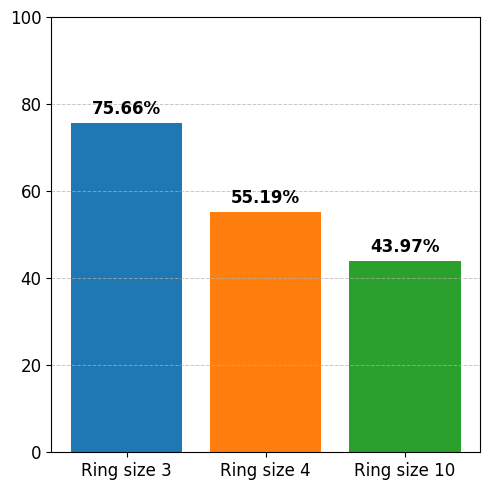

In [83]:
import matplotlib.pyplot as plt

# Labels for the percentages
labels = ['Ring size 3', 'Ring size 4', 'Ring size 10']
percentages = [round(mix_2, 2), round(mix_4, 2), round(mix_10, 2)]

# Create the bar chart
plt.figure(figsize=(5, 5))

bars = plt.bar(labels, percentages, color=['#1f77b4', '#ff7f0e', '#2ca02c'])



# Set the range for y-axis
plt.ylim(0, 100)

# Add grid lines
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Customize the ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Display the values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval}%', ha='center', fontsize=12, fontweight='bold')

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()
